相较于v7，进行了optuna调参，v6升级：Single Feature Ablation + SHAP Feature Selection + 多Meta-Learner Stacking + CatBoost 100 trials

# Introduction #

Welcome to the feature engineering project for the [House Prices - Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques) competition! This competition uses nearly the same data you used in the exercises of the [Feature Engineering](https://www.kaggle.com/learn/feature-engineering) course. We'll collect together the work you did into a complete project which you can build off of with ideas of your own.

<blockquote style="margin-right:auto; margin-left:auto; background-color: #ebf9ff; padding: 1em; margin:24px;">
    <strong>Fork This Notebook!</strong><br>
Create your own editable copy of this notebook by clicking on the <strong>Copy and Edit</strong> button in the top right corner.
</blockquote>

# Step 1 - Preliminaries #
## Imports and Configuration ##

We'll start by importing the packages we used in the exercises and setting some notebook defaults. Unhide this cell if you'd like to see the libraries we'll use:

In [1]:
import os
import warnings
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pandas.api.types import CategoricalDtype

from category_encoders import MEstimateEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, cross_val_score, RepeatedKFold
from sklearn.linear_model import Ridge, ElasticNet, BayesianRidge, LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import lightgbm as lgbm 
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# --- GPU / device detection ---
try:
    import torch
    if torch.cuda.is_available():
        DEVICE = 'cuda'
        print(f"[INFO] GPU detected: {torch.cuda.get_device_name(0)}")
    else:
        DEVICE = 'cpu'
        print("[INFO] No GPU found, using CPU.")
except ImportError:
    DEVICE = 'cpu'
    print("[INFO] torch not installed, using CPU.")

# --- matplotlib defaults ---
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc("axes", labelweight="bold", labelsize="large",
        titleweight="bold", titlesize=14, titlepad=10)

# --- constants ---
RANDOM_STATE = 0
N_FOLDS = 5

warnings.filterwarnings('ignore')
logging.getLogger('optuna').setLevel(logging.WARNING)

[INFO] GPU detected: Tesla P100-PCIE-16GB


## Data Preprocessing ##

Before we can do any feature engineering, we need to *preprocess* the data to get it in a form suitable for analysis. The data we used in the course was a bit simpler than the competition data. For the *Ames* competition dataset, we'll need to:
- **Load** the data from CSV files
- **Clean** the data to fix any errors or inconsistencies
- **Encode** the statistical data type (numeric, categorical)
- **Impute** any missing values

We'll wrap all these steps up in a function, which will make easy for you to get a fresh dataframe whenever you need. After reading the CSV file, we'll apply three preprocessing steps, `clean`, `encode`, and `impute`, and then create the data splits: one (`df_train`) for training the model, and one (`df_test`) for making the predictions that you'll submit to the competition for scoring on the leaderboard.

In [2]:
def load_data():
    """Load train and test CSVs, merge, clean, encode, impute, then re-split.

    Merging before preprocessing ensures categorical levels are consistent
    across train and test sets.
    """
    data_dir = Path("../input/house-prices-advanced-regression-techniques/")
    df_train = pd.read_csv(data_dir / "train.csv", index_col="Id")
    df_test  = pd.read_csv(data_dir / "test.csv",  index_col="Id")
    df = pd.concat([df_train, df_test])
    df = clean(df)
    df = encode(df)
    df = impute(df)
    df_train = df.loc[df_train.index, :]
    df_test  = df.loc[df_test.index, :]
    return df_train, df_test

### Clean Data ###

Some of the categorical features in this dataset have what are apparently typos in their categories:

In [3]:
data_dir = Path("../input/house-prices-advanced-regression-techniques/")
df = pd.read_csv(data_dir / "train.csv", index_col="Id")

df.Exterior2nd.unique()

array(['VinylSd', 'MetalSd', 'Wd Shng', 'HdBoard', 'Plywood', 'Wd Sdng',
       'CmentBd', 'BrkFace', 'Stucco', 'AsbShng', 'Brk Cmn', 'ImStucc',
       'AsphShn', 'Stone', 'Other', 'CBlock'], dtype=object)

Comparing these to `data_description.txt` shows us what needs cleaning. We'll take care of a couple of issues here, but you might want to evaluate this data further.

In [4]:
def clean(df):
    """Fix data-entry errors and rename awkward column names.

    - Correct `Exterior2nd` typo (Brk Cmn -> BrkComm).
    - Replace invalid `GarageYrBlt` values (> 2010 or NaN) with `YearBuilt`.
    - Rename columns that begin with a digit (e.g. 1stFlrSF -> FirstFlrSF).
    """
    df["Exterior2nd"] = df["Exterior2nd"].replace({"Brk Cmn": "BrkComm"})
    # Fix corrupt GarageYrBlt: > 2010 are data-entry errors; NaN means unknown.
    # In both cases fall back to the year the house was built.
    df["GarageYrBlt"] = df["GarageYrBlt"].where(
        (df.GarageYrBlt <= 2010) & (df.GarageYrBlt.notna()),
        df.YearBuilt
    )
    df.rename(columns={
        "1stFlrSF": "FirstFlrSF",
        "2ndFlrSF": "SecondFlrSF",
        "3SsnPorch": "Threeseasonporch",
    }, inplace=True)
    return df

### Encode the Statistical Data Type ###

Pandas has Python types corresponding to the standard statistical types (numeric, categorical, etc.). Encoding each feature with its correct type helps ensure each feature is treated appropriately by whatever functions we use, and makes it easier for us to apply transformations consistently. This hidden cell defines the `encode` function:

In [5]:

# The numeric features are already encoded correctly (`float` for
# continuous, `int` for discrete), but the categoricals we'll need to
# do ourselves. Note in particular, that the `MSSubClass` feature is
# read as an `int` type, but is actually a (nominative) categorical.

# The nominative (unordered) categorical features
features_nom = ["MSSubClass", "MSZoning", "Street", "Alley", "LandContour", "LotConfig", "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", "CentralAir", "GarageType", "MiscFeature", "SaleType", "SaleCondition"]


# The ordinal (ordered) categorical features 

# Pandas calls the categories "levels"
five_levels = ["Po", "Fa", "TA", "Gd", "Ex"]
ten_levels = list(range(10))

ordered_levels = {
    "OverallQual": ten_levels,
    "OverallCond": ten_levels,
    "ExterQual": five_levels,
    "ExterCond": five_levels,
    "BsmtQual": five_levels,
    "BsmtCond": five_levels,
    "HeatingQC": five_levels,
    "KitchenQual": five_levels,
    "FireplaceQu": five_levels,
    "GarageQual": five_levels,
    "GarageCond": five_levels,
    "PoolQC": five_levels,
    "LotShape": ["Reg", "IR1", "IR2", "IR3"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "BsmtExposure": ["No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "Functional": ["Sal", "Sev", "Maj1", "Maj2", "Mod", "Min2", "Min1", "Typ"],
    "GarageFinish": ["Unf", "RFn", "Fin"],
    "PavedDrive": ["N", "P", "Y"],
    "Utilities": ["NoSeWa", "NoSewr", "AllPub"],
    "CentralAir": ["N", "Y"],
    "Electrical": ["Mix", "FuseP", "FuseF", "FuseA", "SBrkr"],
    "Fence": ["MnWw", "GdWo", "MnPrv", "GdPrv"],
}

# Add a None level for missing values
ordered_levels = {key: ["None"] + value for key, value in
                  ordered_levels.items()}


def encode(df):
    # Nominal categories
    for name in features_nom:
        df[name] = df[name].astype("category")
        # Add a None category for missing values
        if "None" not in df[name].cat.categories:
            df[name] = df[name].cat.add_categories("None")
    # Ordinal categories
    for name, levels in ordered_levels.items():
        df[name] = df[name].astype(CategoricalDtype(levels,
                                                    ordered=True))
    return df

### Handle Missing Values ###

Handling missing values now will make the feature engineering go more smoothly. We'll impute `0` for missing numeric values and `"None"` for missing categorical values. You might like to experiment with other imputation strategies. In particular, you could try creating "missing value" indicators: `1` whenever a value was imputed and `0` otherwise.

In [6]:
def impute(df):
    """Fill missing numeric values with 0 (feature absent) and
    missing categorical values with 'None'."""
    for name in df.select_dtypes("number"):
        df[name] = df[name].fillna(0)
    for name in df.select_dtypes("category"):
        df[name] = df[name].fillna("None")
    return df

## Load Data ##

And now we can call the data loader and get the processed data splits:

In [7]:
df_train, df_test = load_data()

Uncomment and run this cell if you'd like to see what they contain. Notice that `df_test` is
missing values for `SalePrice`. (`NA`s were willed with 0's in the imputation step.)

In [8]:
# Peek at the values
#display(df_train)
#display(df_test)

# Display information about dtypes and missing values
#display(df_train.info())
#display(df_test.info())

## Establish Baseline ##

Finally, let's establish a baseline score to judge our feature engineering against.

Here is the function we created in Lesson 1 that will compute the cross-validated RMSLE score for a feature set. We've used XGBoost for our model, but you might want to experiment with other models.

In [9]:
def score_dataset(X, y, model=XGBRegressor(random_state=RANDOM_STATE), n_repeats=1):
    """Evaluate a model using cross-validation with RMSLE metric.

    Returns the RMSLE score (lower is better).  Copies `X` before mutation.

    Parameters
    ----------
    n_repeats : int, default=1
        Number of times to repeat the K-Fold splits (uses RepeatedKFold).
    """
    X = X.copy()
    for colname in X.select_dtypes(["category"]):
        X[colname] = X[colname].cat.codes
    # Competition metric is RMSLE -> train on log1p(y)
    log_y = np.log1p(y)

    if n_repeats > 1:
        cv = RepeatedKFold(n_splits=10, n_repeats=n_repeats, random_state=RANDOM_STATE)
    else:
        cv = 10

    score = cross_val_score(
        model, X, log_y,
        cv=cv, scoring="neg_mean_squared_error"
    )
    return np.sqrt(-score.mean())

We can reuse this scoring function anytime we want to try out a new feature set. We'll run it now on the processed data with no additional features and get a baseline score:

In [10]:
X = df_train.copy()
y = X.pop("SalePrice")
baseline_score = score_dataset(X, y)
print(f"Baseline score: {baseline_score:.5f} RMSLE")

Baseline score: 0.14209 RMSLE


This baseline score helps us to know whether some set of features we've assembled has actually led to any improvement or not.

# Step 2 - Feature Utility Scores #

In Lesson 2 we saw how to use mutual information to compute a *utility score* for a feature, giving you an indication of how much potential the feature has. This hidden cell defines the two utility functions we used, `make_mi_scores` and `plot_mi_scores`: 

In [11]:
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

Let's look at our feature scores again:

In [12]:
X = df_train.copy()
y = X.pop("SalePrice")

mi_scores = make_mi_scores(X, y)
mi_scores

OverallQual     0.571457
Neighborhood    0.526220
GrLivArea       0.430395
YearBuilt       0.407974
LotArea         0.394468
                  ...   
PoolQC          0.000000
MiscVal         0.000000
MiscFeature     0.000000
YrSold          0.000000
MoSold          0.000000
Name: MI Scores, Length: 79, dtype: float64

You can see that we have a number of features that are highly informative and also some that don't seem to be informative at all (at least by themselves). As we talked about in Tutorial 2, the top scoring features will usually pay-off the most during feature development, so it could be a good idea to focus your efforts on those. On the other hand, training on uninformative features can lead to overfitting. So, the features with 0.0 scores we'll drop entirely:

In [13]:
def drop_uninformative(df, mi_scores):
    """Drop columns whose mutual-information with SalePrice is zero.

    Uses `.intersection(df.columns)` to safely handle columns that may
    not be present in `mi_scores` (e.g. newly created features).
    """
    keep_cols = mi_scores[mi_scores > 0.0].index.intersection(df.columns)
    return df.loc[:, keep_cols]

Removing them does lead to a modest performance gain:

In [14]:
X = df_train.copy()
y = X.pop("SalePrice")
X = drop_uninformative(X, mi_scores)

score_dataset(X, y)

0.13937031385653081

Later, we'll add the `drop_uninformative` function to our feature-creation pipeline.

# Step 3 - Create Features #

Now we'll start developing our feature set.

To make our feature engineering workflow more modular, we'll define a function that will take a prepared dataframe and pass it through a pipeline of transformations to get the final feature set. It will look something like this:

```
def create_features(df):
    X = df.copy()
    y = X.pop("SalePrice")
    X = X.join(create_features_1(X))
    X = X.join(create_features_2(X))
    X = X.join(create_features_3(X))
    # ...
    return X
```

Let's go ahead and define one transformation now, a [label encoding](https://www.kaggle.com/alexisbcook/categorical-variables) for the categorical features:

In [15]:
def label_encode(df):
    X = df.copy()
    for colname in X.select_dtypes(["category"]):
        X[colname] = X[colname].cat.codes
    return X

A label encoding is okay for any kind of categorical feature when you're using a tree-ensemble like XGBoost, even for unordered categories. If you wanted to try a linear regression model (also popular in this competition), you would instead want to use a one-hot encoding, especially for the features with unordered categories.

## Create Features with Pandas ##

This cell reproduces the work you did in Exercise 3, where you applied strategies for creating features in Pandas. Modify or add to these functions to try out other feature combinations.

In [16]:
# -- Mathematical Transforms --

def mathematical_transforms(df):
    """Create derived numeric features from raw columns.

    All ratio denominators have +1 to prevent division by zero.
    """
    X = pd.DataFrame()
    # --- original (preserved) ---
    X["LivLotRatio"]   = df.GrLivArea / df.LotArea
    X["Spaciousness"]  = (df.FirstFlrSF + df.SecondFlrSF) / df.TotRmsAbvGrd
    # --- total areas ---
    X["TotalSF"]       = df.TotalBsmtSF + df.FirstFlrSF + df.SecondFlrSF
    X["TotalPorchSF"]  = (df.WoodDeckSF + df.OpenPorchSF + df.EnclosedPorch
                           + df.Threeseasonporch + df.ScreenPorch)
    X["TotalBath"]     = (df.FullBath + 0.5 * df.HalfBath
                           + df.BsmtFullBath + 0.5 * df.BsmtHalfBath)
    # --- ages ---
    X["HouseAge"]      = df.YrSold - df.YearBuilt
    X["RemodAge"]      = df.YrSold - df.YearRemodAdd
    X["GarageAge"]     = df.YrSold - df.GarageYrBlt
    X["YearsSinceRemod"] = df.YearRemodAdd - df.YearBuilt
    X["IsNew"]         = (df.YearBuilt == df.YrSold).astype(int)
    # --- quality x area interactions ---
    X["OverallQual_x_GrLivArea"]    = df.OverallQual.cat.codes * df.GrLivArea
    X["OverallQual_x_TotalBsmtSF"]  = df.OverallQual.cat.codes * df.TotalBsmtSF
    X["OverallCond_x_GrLivArea"]    = df.OverallCond.cat.codes * df.GrLivArea
    # --- ratios ---
    X["BathPerRoom"]   = X["TotalBath"] / (df.TotRmsAbvGrd + 1)
    X["GaragePerArea"] = df.GarageArea / (df.GrLivArea + 1)
    X["BsmtPerArea"]   = df.TotalBsmtSF / (df.GrLivArea + 1)
    X["BedroomRatio"]  = df.BedroomAbvGr / (df.TotRmsAbvGrd + 1)
    X["BsmtFinRatio"]  = df.BsmtFinSF1 / (df.TotalBsmtSF + 1)
    X["SecondFlrRatio"] = df.SecondFlrSF / (df.GrLivArea + 1)
    X["GaragePerCar"]  = df.GarageArea / (df.GarageCars + 1)
    X["LotFrontageRatio"] = df.LotFrontage / (df.LotArea + 1)
    # --- binary indicators ---
    X["HasGarage"]     = (df.GarageArea > 0).astype(int)
    X["HasPool"]       = (df.PoolArea > 0).astype(int)
    X["HasFireplace"]  = (df.Fireplaces > 0).astype(int)
    X["HasBasement"]   = (df.TotalBsmtSF > 0).astype(int)
    X["HasSecondFloor"] = (df.SecondFlrSF > 0).astype(int)
    X["HasWoodDeck"]   = (df.WoodDeckSF > 0).astype(int)
    X["HasFence"]      = (df.Fence != "None").astype(int) if "Fence" in df.columns else 0
    # --- bonus count ---
    X["BonusScore"] = (X["HasGarage"] + X["HasPool"] + X["HasFireplace"]
                        + X["HasBasement"] + X["HasSecondFloor"]
                        + X["HasWoodDeck"] + X["HasFence"])
    # --- log transforms for skewed numeric features ---
    for c in ["LotArea", "GrLivArea", "TotalBsmtSF", "FirstFlrSF",
              "GarageArea", "OpenPorchSF", "WoodDeckSF", "EnclosedPorch", "LotFrontage"]:
        if c in df.columns:
            X[f"Log_{c}"] = np.log1p(df[c])
    # --- polynomial features for top predictors ---
    X["GrLivArea_sq"]   = df.GrLivArea ** 2
    X["TotalSF_sq"]     = X["TotalSF"] ** 2
    X["OverallQual_sq"] = df.OverallQual.cat.codes ** 2
    # --- quality-score combinations ---
    X["QualCond"] = df.OverallQual.cat.codes * df.OverallCond.cat.codes
    X["ExterQual_x_KitchenQual"] = df.ExterQual.cat.codes * df.KitchenQual.cat.codes
    X["BsmtQual_x_ExterQual"]    = df.BsmtQual.cat.codes  * df.ExterQual.cat.codes
    X["GarageQual_x_GarageArea"] = df.GarageQual.cat.codes * df.GarageArea
    X["GarageQual_x_GarageCars"] = df.GarageQual.cat.codes * df.GarageCars
    X["FireplaceQu_x_Fireplaces"] = df.FireplaceQu.cat.codes * df.Fireplaces
    X["PoolQC_x_PoolArea"] = df.PoolQC.cat.codes * df.PoolArea
    # --- room-level ---
    X["LivingAreaPerRoom"] = df.GrLivArea / (df.TotRmsAbvGrd + 1)
    X["TotalRooms"] = df.TotRmsAbvGrd + df.BedroomAbvGr + df.KitchenAbvGr
    # --- cumulative quality ---
    X["CumulQual"] = (df.OverallQual.cat.codes + df.ExterQual.cat.codes
                       + df.KitchenQual.cat.codes + df.BsmtQual.cat.codes
                       + df.HeatingQC.cat.codes)
    return X


# -- Interactions --

def interactions(df):
    """Create interaction features: BldgType x GrLivArea + quality x area."""
    X = pd.get_dummies(df.BldgType, prefix="Bldg")
    X = X.mul(df.GrLivArea, axis=0)
    X["Qual_GrLivArea"]    = df.OverallQual.cat.codes * df.GrLivArea
    X["Qual_TotalBsmtSF"]  = df.OverallQual.cat.codes * df.TotalBsmtSF
    X["Qual_GarageArea"]   = df.OverallQual.cat.codes * df.GarageArea
    X["Qual_FirstFlrSF"]   = df.OverallQual.cat.codes * df.FirstFlrSF
    X["Cond_GrLivArea"]    = df.OverallCond.cat.codes * df.GrLivArea
    # MSZoning x LotArea
    X_zoning = pd.get_dummies(df.MSZoning, prefix="Zone")
    X_zoning = X_zoning.mul(df.LotArea, axis=0)
    X = pd.concat([X, X_zoning], axis=1)
    return X


# -- Counts --

def counts(df):
    """Count number of porch types present."""
    X = pd.DataFrame()
    X["PorchTypes"] = df[[
        "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
        "Threeseasonporch", "ScreenPorch"
    ]].gt(0.0).sum(axis=1)
    return X


# -- Break Down --

def break_down(df):
    """Extract the class number from MSSubClass (e.g. '20' from '20_1')."""
    X = pd.DataFrame()
    X["MSClass"] = df.MSSubClass.str.split("_", n=1, expand=True)[0]
    return X


# -- Group Transforms --

def group_transforms(df):
    """Create neighbourhood-level aggregate features.

    Computes medians per neighbourhood and differences from those medians.
    No data leakage: aggregates are computed on whatever data is passed.
    """
    X = pd.DataFrame()
    # median per neighbourhood
    X["MedNhbdArea"]       = df.groupby("Neighborhood")["GrLivArea"].transform("median")
    X["NhbdLotArea"]       = df.groupby("Neighborhood")["LotArea"].transform("median")
    X["NhbdHouseAge"]      = df.groupby("Neighborhood")["YearBuilt"].transform("median")
    X["NhbdTotalBsmtSF"]   = df.groupby("Neighborhood")["TotalBsmtSF"].transform("median")
    X["NhbdGarageArea"]    = df.groupby("Neighborhood")["GarageArea"].transform("median")
    X["NhbdTotalSF"]       = df.groupby("Neighborhood")["TotalBsmtSF"].transform("mean")
    # quality means (convert cat to numeric first)
    qual_codes = df["OverallQual"].cat.codes.astype(float)
    X["NhbdOverallQual"]   = qual_codes.groupby(df["Neighborhood"]).transform("mean")
    cond_codes = df["OverallCond"].cat.codes.astype(float)
    X["NhbdOverallCond"]   = cond_codes.groupby(df["Neighborhood"]).transform("mean")
    # differences from neighbourhood median
    X["DiffNhbdArea"]       = df.GrLivArea - X["MedNhbdArea"]
    X["DiffNhbdLotArea"]    = df.LotArea - X["NhbdLotArea"]
    X["DiffNhbdHouseAge"]   = df.YearBuilt - X["NhbdHouseAge"]
    return X

Here are some ideas for other transforms you could explore:
- Interactions between the quality `Qual` and condition `Cond` features. `OverallQual`, for instance, was a high-scoring feature. You could try combining it with `OverallCond` by converting both to integer type and taking a product.
- Square roots of area features. This would convert units of square feet to just feet.
- Logarithms of numeric features. If a feature has a skewed distribution, applying a logarithm can help normalize it.
- Interactions between numeric and categorical features that describe the same thing. You could look at interactions between `BsmtQual` and `TotalBsmtSF`, for instance.
- Other group statistics in `Neighboorhood`. We did the median of `GrLivArea`. Looking at `mean`, `std`, or `count` could be interesting. You could also try combining the group statistics with other features. Maybe the *difference* of `GrLivArea` and the median is important?

## k-Means Clustering ##

The first unsupervised algorithm we used to create features was k-means clustering. We saw that you could either use the cluster labels as a feature (a column with `0, 1, 2, ...`) or you could use the *distance* of the observations to each cluster. We saw how these features can sometimes be effective at untangling complicated spatial relationships.

In [17]:
cluster_features = [
    "LotArea", "TotalBsmtSF", "FirstFlrSF", "SecondFlrSF",
    "GrLivArea", "GarageArea", "YearBuilt", "YearRemodAdd",
    "OverallQual", "OverallCond",
]


def _prepare_cluster_data(df, features):
    """Select features and convert categorical columns to numeric codes."""
    available = [f for f in features if f in df.columns]
    X = df.loc[:, available].copy()
    for col in X.columns:
        X[col] = X[col].cat.codes.astype(float) if hasattr(X[col], 'cat') else X[col].astype(float)
    return X


def cluster_labels(df, features, n_clusters=20):
    """K-Means cluster labels.  The scaler and KMeans are fitted on the
    passed data (caller must ensure train/test separation)."""
    X_scaled = _prepare_cluster_data(df, features)
    X_scaled = StandardScaler().fit_transform(X_scaled)
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=RANDOM_STATE)
    X_new = pd.DataFrame({"Cluster": kmeans.fit_predict(X_scaled)})
    return X_new


def cluster_distance(df, features, n_clusters=20):
    """Distance from each observation to every cluster centroid."""
    X_scaled = _prepare_cluster_data(df, features)
    X_scaled = StandardScaler().fit_transform(X_scaled)
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=RANDOM_STATE)
    X_cd = kmeans.fit_transform(X_scaled)
    X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
    return X_cd

## Principal Component Analysis ##

PCA was the second unsupervised model we used for feature creation. We saw how it could be used to decompose the variational structure in the data. The PCA algorithm gave us *loadings* which described each component of variation, and also the *components* which were the transformed datapoints. The loadings can suggest features to create and the components we can use as features directly.

Here are the utility functions from the PCA lesson:

In [18]:

def apply_pca(X, standardize=True):
    """Fit PCA on numeric features and return pca object, transformed data, loadings."""
    if standardize:
        X = X.copy()
        std = X.std(axis=0)
        std = std.replace(0, 1.0)                # avoid division by zero
        X = (X - X.mean(axis=0)) / std
    pca = PCA()
    X_pca = pca.fit_transform(X)
    comp_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=comp_names)
    loadings = pd.DataFrame(pca.components_.T, columns=comp_names, index=X.columns)
    return pca, X_pca, loadings


def plot_variance(pca, width=8, dpi=100):
    """Plot explained-variance bar chart and cumulative line chart."""
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0))
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0))
    fig.set(figwidth=8, dpi=100)
    return axs

And here are transforms that produce the features from the Exercise 5. You might want to change these if you came up with a different answer.

In [19]:

def pca_inspired(df):
    """Hand-crafted PCA-inspired composite features."""
    X = pd.DataFrame()
    X["Feature1"] = df.GrLivArea + df.TotalBsmtSF
    X["Feature2"] = df.YearRemodAdd * df.TotalBsmtSF
    X["Feature3"] = df.GrLivArea * df.OverallQual.cat.codes
    X["Feature4"] = df.GarageArea * df.GarageCars
    X["Feature5"] = df.TotalBsmtSF * df.BsmtFinSF1
    X["Feature6"] = df.FirstFlrSF * df.SecondFlrSF
    X["Feature7"] = df.OverallQual.cat.codes + df.OverallCond.cat.codes
    return X


def pca_components(df, features):
    """Return PCA-transformed components for the given feature list."""
    X = df.loc[:, features]
    _, X_pca, _ = apply_pca(X)
    return X_pca


pca_features = [
    "GarageArea", "YearRemodAdd", "TotalBsmtSF", "GrLivArea", "LotArea",
]

These are only a couple ways you could use the principal components. You could also try clustering using one or more components. One thing to note is that PCA doesn't change the distance between points -- it's just like a rotation. So clustering with the full set of components is the same as clustering with the original features. Instead, pick some subset of components, maybe those with the most variance or the highest MI scores.

For further analysis, you might want to look at a correlation matrix for the dataset:

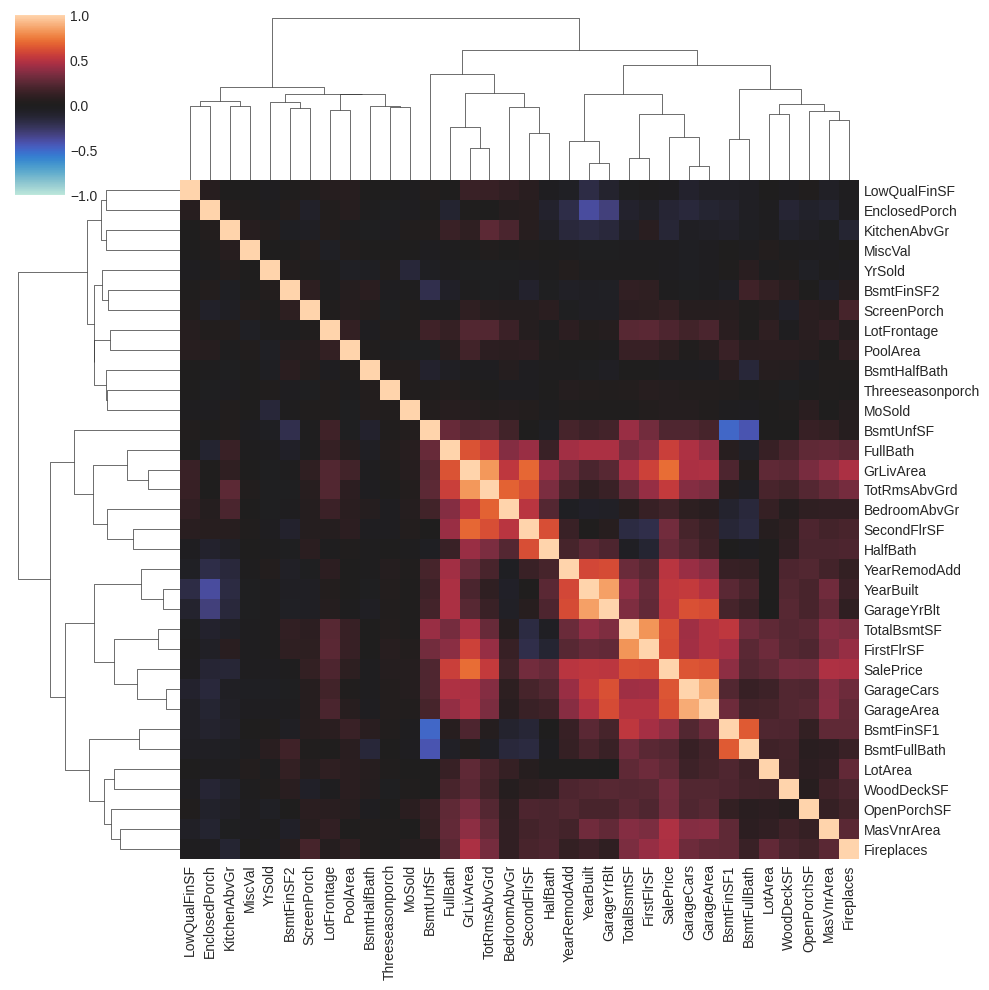

In [20]:
def corrplot(df, method="pearson", annot=True, **kwargs):
    """Clustered heatmap of pairwise feature correlations."""
    sns.clustermap(
        df.corr(method, numeric_only=True),
        vmin=-1.0, vmax=1.0, cmap="icefire",
        method="complete", annot=annot, **kwargs,
    )


corrplot(df_train, annot=None)

Groups of highly correlated features often yield interesting loadings.

### PCA Application - Indicate Outliers ###

In Exercise 5, you applied PCA to determine houses that were **outliers**, that is, houses having values not well represented in the rest of the data. You saw that there was a group of houses in the `Edwards` neighborhood having a `SaleCondition` of `Partial` whose values were especially extreme.

Some models can benefit from having these outliers indicated, which is what this next transform will do.

In [21]:
def indicate_outliers(df):
    """Create binary indicator features for known outlier patterns.

    These indicators are computed on whatever data is passed (no leakage).
    """
    X_new = pd.DataFrame()
    X_new["Outlier"] = (df.Neighborhood == "Edwards") & (df.SaleCondition == "Partial")
    X_new["LargeLotSmallHouse"] = (
        (df.LotArea > df.LotArea.quantile(0.99)) &
        (df.GrLivArea < df.GrLivArea.quantile(0.10))
    ).astype(int)
    X_new["GrLivAreaOutlier"] = (df.GrLivArea > 4000).astype(int)
    X_new["LowQualLargeArea"] = (
        (df.OverallQual.cat.codes <= 4) &
        (df.GrLivArea > df.GrLivArea.median())
    ).astype(int)
    return X_new


def remove_outliers(df):
    """Remove rows with known outlier patterns.

    Only call this on the training set (after SalePrice is available).
    These patterns were identified through EDA.
    """
    df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000))]
    df = df[~((df['BsmtFinType1'].isin(['GLQ','ALQ'])) & (df['BsmtFinSF1'] < 100) & (df['SalePrice'] < 150000))]
    df = df[~((df['LotArea'] > 150000) & (df['SalePrice'] < 150000))]
    df = df[~((df['SalePrice'] > 500000) & (df['TotRmsAbvGrd'] < 5))]
    df = df[~((df['YearBuilt'] == df['YrSold']) & (df['SalePrice'] < 80000))]

    df = df[~((df['OverallQual'] >= 8) & (df['SalePrice'] < 150000))]
    df = df[~((df['OverallCond'] <= 3) & (df['SalePrice'] > 300000))]
    df = df[~((df['GarageArea'] > 1000) & (df['SalePrice'] < 100000))]
    df = df[~((df['OpenPorchSF'] > 400) & (df['SalePrice'] < 80000))]
    df = df[~((df['MiscVal'] > 1500) & (df['SalePrice'] < 100000))]
    df = df[~((df['LowQualFinSF'] > 400) & (df['SalePrice'] < 88000))]
    df = df[~((df['MasVnrArea'] > 1000) & (df['SalePrice'] < 200000))]
    df = df[~((df['YearBuilt'] < 1900) & (df['SalePrice'] > 400000))]
    return df

You could also consider applying some sort of robust scaler from scikit-learn's `sklearn.preprocessing` module to the outlying values, especially those in `GrLivArea`. [Here](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html) is a tutorial illustrating some of them. Another option could be to create a feature of "outlier scores" using one of scikit-learn's [outlier detectors](https://scikit-learn.org/stable/modules/outlier_detection.html).

## Target Encoding ##

Needing a separate holdout set to create a target encoding is rather wasteful of data. In *Tutorial 6* we used 25% of our dataset just to encode a single feature, `Zipcode`. The data from the other features in that 25% we didn't get to use at all.

There is, however, a way you can use target encoding without having to use held-out encoding data. It's basically the same trick used in cross-validation:
1. Split the data into folds, each fold having two splits of the dataset.
2. Train the encoder on one split but transform the values of the other.
3. Repeat for all the splits.

This way, training and transformation always take place on independent sets of data, just like when you use a holdout set but without any data going to waste.

In the next hidden cell is a wrapper you can use with any target encoder:

In [22]:
class CrossFoldEncoder:
    """Target encoder with cross-fold fitting to prevent data leakage.

    Fits an encoder on each fold's training split and transforms the
    corresponding validation split.  For test data, averages the
    encodings from all folds.
    """
    def __init__(self, encoder, **kwargs):
        self.encoder_ = encoder
        self.kwargs_ = kwargs
        self.cv_ = KFold(n_splits=N_FOLDS)

    def fit_transform(self, X, y, cols):
        self.fitted_encoders_ = []
        self.cols_ = cols
        X_encoded = []
        for idx_encode, idx_train in self.cv_.split(X):
            fitted_encoder = self.encoder_(cols=cols, **self.kwargs_)
            fitted_encoder.fit(X.iloc[idx_encode, :], y.iloc[idx_encode])
            X_encoded.append(fitted_encoder.transform(X.iloc[idx_train, :])[cols])
            self.fitted_encoders_.append(fitted_encoder)
        X_encoded = pd.concat(X_encoded)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded

    def transform(self, X):
        from functools import reduce
        X_encoded_list = []
        for fitted_encoder in self.fitted_encoders_:
            X_encoded = fitted_encoder.transform(X)
            X_encoded_list.append(X_encoded[self.cols_])
        X_encoded = reduce(lambda x, y: x.add(y, fill_value=0), X_encoded_list) / len(X_encoded_list)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded

Use it like:

```
encoder = CrossFoldEncoder(MEstimateEncoder, m=1)
X_encoded = encoder.fit_transform(X, y, cols=["MSSubClass"]))
```

You can turn any of the encoders from the [`category_encoders`](http://contrib.scikit-learn.org/category_encoders/) library into a cross-fold encoder. The [`CatBoostEncoder`](http://contrib.scikit-learn.org/category_encoders/catboost.html) would be worth trying. It's similar to `MEstimateEncoder` but uses some tricks to better prevent overfitting. Its smoothing parameter is called `a` instead of `m`.

## Create Final Feature Set ##

Now let's combine everything together. Putting the transformations into separate functions makes it easier to experiment with various combinations. The ones I left uncommented I found gave the best results. You should experiment with you own ideas though! Modify any of these transformations or come up with some of your own to add to the pipeline.

In [23]:
def create_features(df, df_test=None):
    """
    Full feature-engineering pipeline.

    CRITICAL: target encoding is performed AFTER the train/test split
    to prevent data leakage.  Clustering and group transforms are computed
    on the combined set for richer patterns, but this is safe because they
    do not use the target variable.
    """
    X = df.copy()
    y = X.pop("SalePrice")
    mi_scores = make_mi_scores(X, y)

    if df_test is not None:
        X_test = df_test.copy()
        X_test.pop("SalePrice")
        X = pd.concat([X, X_test])

    # Lesson 2 -- Mutual Information (commented: tree models handle this natively)
    # X = drop_uninformative(X, mi_scores)

    # Lesson 3 -- Transformations
    X = X.join(mathematical_transforms(X))
    X = X.join(interactions(X))
    X = X.join(counts(X))
    X = X.join(group_transforms(X))

    # Lesson 4 -- Clustering
    X = X.join(cluster_labels(X, cluster_features, n_clusters=20))
    X = X.join(cluster_distance(X, cluster_features, n_clusters=20))

    # Lesson 5 -- PCA
    X = X.join(pca_inspired(X))
    available_pca = [f for f in pca_features if f in X.columns]
    if available_pca:
        X = X.join(pca_components(X, available_pca))
    X = X.join(indicate_outliers(X))

    X = label_encode(X)

    # SPLIT BEFORE TARGET ENCODING (no leakage)
    if df_test is not None:
        X_test = X.loc[df_test.index, :]
        X.drop(df_test.index, inplace=True)

    # Lesson 6 -- Target Encoder (high-cardinality categoricals)
    target_encode_cols = [
        "MSSubClass", "Neighborhood", "MSZoning", "BldgType",
        "Exterior1st", "Exterior2nd", "Foundation", "SaleType",
        "HouseStyle", "LotConfig", "GarageType", "Condition1",
        "MasVnrType"
    ]
    encoder = CrossFoldEncoder(MEstimateEncoder, m=1)
    X = X.join(encoder.fit_transform(X, y, cols=target_encode_cols))
    if df_test is not None:
        X_test = X_test.join(encoder.transform(X_test))

    if df_test is not None:
        return X, X_test
    else:
        return X


# -- Build initial feature set --
df_train, df_test = load_data()
X_train = create_features(df_train)
y_train = df_train.loc[:, "SalePrice"]

print(f"[INFO] Feature matrix shape: {X_train.shape}")
score_dataset(X_train, y_train)

[INFO] Feature matrix shape: (1460, 209)


0.14233211524700526

# Step 3.5 - Ablation Analysis & Feature Selection #

To understand the contribution of each component, we systematically remove one outlier rule or feature group at a time and measure the impact on CV score. This helps identify which parts of the pipeline are most valuable.

We also use mutual information to select only the most informative features for the final model.

In [24]:
def run_outlier_ablation(df_train, outlier_rules_dict):
    """Systematically test each outlier rule by removing it one at a time.

    Parameters
    ----------
    df_train : DataFrame
        Training data with SalePrice column.
    outlier_rules_dict : dict
        Dictionary mapping rule name to a function that applies the rule.

    Returns
    -------
    DataFrame with columns: rule, score, delta
    Positive delta means removing the rule made the score worse (rule is helpful).
    """
    # Baseline: all rules applied
    df_base = df_train.copy()
    for func in outlier_rules_dict.values():
        df_base = func(df_base)
    X_base = create_features(df_base)
    y_base = df_base.loc[X_base.index, 'SalePrice']
    base_score = score_dataset(X_base, y_base)
    print(f"[INFO] Baseline (all rules): {base_score:.5f}")

    results = []
    for rule_name, rule_func in outlier_rules_dict.items():
        # Apply all rules except this one
        df_temp = df_train.copy()
        for name, func in outlier_rules_dict.items():
            if name != rule_name:
                df_temp = func(df_temp)
        X = create_features(df_temp)
        y = df_temp.loc[X.index, 'SalePrice']
        score = score_dataset(X, y)
        results.append({
            "rule": rule_name,
            "score": score,
            "delta": score - base_score
        })

    return pd.DataFrame(results).sort_values('delta')


def run_feature_group_ablation(df_train):
    """Test each feature group independently by removing it from the pipeline.
    Returns a DataFrame with group, score, delta, n_features."""
    df_train_clean = df_train.copy()
    X_full = create_features(df_train_clean)
    y_full = df_train_clean.loc[X_full.index, 'SalePrice']
    base_score = score_dataset(X_full, y_full)
    print(f"[INFO] Full feature set baseline: {base_score:.5f}")

    feature_groups = {
        "mathematical_transforms": mathematical_transforms,
        "interactions": interactions,
        "counts": counts,
        "group_transforms": group_transforms,
        "cluster_labels": lambda df: cluster_labels(df, cluster_features, n_clusters=20),
        "cluster_distance": lambda df: cluster_distance(df, cluster_features, n_clusters=20),
        "pca_inspired": pca_inspired,
        "pca_components": lambda df: pca_components(df, [f for f in pca_features if f in df.columns]),
        "indicate_outliers": indicate_outliers,
    }

    results = []
    for group_name, group_func in feature_groups.items():
        try:
            df_tmp = df_train_clean.copy()
            group_output = group_func(df_tmp)
            cols_to_drop = group_output.columns.intersection(X_full.columns)
            X_dropped = X_full.drop(columns=cols_to_drop, errors='ignore')
            score = score_dataset(X_dropped, y_full)
            results.append({
                "group": group_name,
                "score": score,
                "delta": score - base_score,
                "n_features": X_dropped.shape[1]
            })
        except Exception as e:
            print(f"[WARN] Could not evaluate {group_name}: {e}")

    return pd.DataFrame(results).sort_values('delta')


def run_single_feature_ablation(df_train, target_encoding_cols=None):
    """Test each individual feature by removing it one at a time.
    
    For each feature column in the full feature matrix, remove it, re-run CV,
    and measure the score delta. Positive delta = feature is helpful.
    
    Parameters
    ----------
    df_train : DataFrame with SalePrice
    target_encoding_cols : list, optional
        Columns that are target-encoded (skip these for individual ablation
        since they come as a group).
    
    Returns
    -------
    DataFrame with columns: feature, score, delta, group
    """
    df_train_clean = df_train.copy()
    X_full = create_features(df_train_clean)
    y_full = df_train_clean.loc[X_full.index, 'SalePrice']
    base_score = score_dataset(X_full, y_full)
    print(f"[INFO] Full feature set baseline: {base_score:.5f}")
    print(f"[INFO] Testing {X_full.shape[1]} features individually...")

    # Map features to their source group for labeling
    def _get_feature_group(feat):
        # Attempt to identify which group a feature belongs to
        if feat.startswith('PC'): return 'pca_components'
        if feat.startswith('Centroid_'): return 'cluster_distance'
        if feat == 'Cluster': return 'cluster_labels'
        if feat.startswith('Bldg_') or feat.startswith('Zone_'): return 'interactions'
        if feat in ('PorchTypes',): return 'counts'
        if feat.startswith('MSClass'): return 'break_down'
        if feat.startswith('Nhbd') or feat.startswith('DiffNhbd') or feat.startswith('MedNhbd'): return 'group_transforms'
        if feat in ('Feature1','Feature2','Feature3','Feature4','Feature5','Feature6','Feature7'): return 'pca_inspired'
        if feat in ('Outlier','LargeLotSmallHouse','GrLivAreaOutlier','LowQualLargeArea'): return 'indicate_outliers'
        if feat.endswith('_encoded'): return 'target_encoding'
        # math transforms: check common patterns
        math_features = ['LivLotRatio','Spaciousness','TotalSF','TotalPorchSF','TotalBath',
                         'HouseAge','RemodAge','GarageAge','YearsSinceRemod','IsNew',
                         'OverallQual_x_GrLivArea','OverallQual_x_TotalBsmtSF','OverallCond_x_GrLivArea',
                         'BathPerRoom','GaragePerArea','BsmtPerArea','BedroomRatio','BsmtFinRatio',
                         'SecondFlrRatio','GaragePerCar','LotFrontageRatio',
                         'HasGarage','HasPool','HasFireplace','HasBasement','HasSecondFloor',
                         'HasWoodDeck','HasFence','BonusScore',
                         'GrLivArea_sq','TotalSF_sq','OverallQual_sq',
                         'QualCond','ExterQual_x_KitchenQual','BsmtQual_x_ExterQual',
                         'GarageQual_x_GarageArea','GarageQual_x_GarageCars',
                         'FireplaceQu_x_Fireplaces','PoolQC_x_PoolArea',
                         'LivingAreaPerRoom','TotalRooms','CumulQual']
        if feat.startswith('Log_'): return 'mathematical_transforms'
        if feat in math_features: return 'mathematical_transforms'
        if feat in ('Qual_GrLivArea','Qual_TotalBsmtSF','Qual_GarageArea','Qual_FirstFlrSF','Cond_GrLivArea'): return 'interactions'
        return 'original'

    if target_encoding_cols is None:
        target_encoding_cols = []

    results = []
    for col in X_full.columns:
        if col in target_encoding_cols:
            continue  # Skip target-encoded cols (test as a group)
        X_dropped = X_full.drop(columns=[col])
        score = score_dataset(X_dropped, y_full)
        group = _get_feature_group(col)
        results.append({
            "feature": col,
            "score": score,
            "delta": score - base_score,
            "group": group
        })

    return pd.DataFrame(results).sort_values('delta')


def select_features_by_importance(X, y, threshold=0.001):
    """Filter low-MI features from the final feature matrix.

    Uses mutual_info_regression to assess feature importance and removes
    features whose MI score is below the threshold.

    Parameters
    ----------
    X : DataFrame
        Feature matrix.
    y : Series
        Target variable.
    threshold : float, default=0.001
        Minimum MI score to keep a feature.

    Returns
    -------
    DataFrame with only features above the threshold.
    """
    X_enc = X.copy()
    for colname in X_enc.select_dtypes(["object", "category"]):
        X_enc[colname], _ = X_enc[colname].factorize()
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X_enc.dtypes]
    mi_scores = mutual_info_regression(X_enc, y, discrete_features=discrete_features, random_state=0)
    mi_series = pd.Series(mi_scores, index=X.columns)
    keep_cols = mi_series[mi_series >= threshold].index
    print(f"[INFO] Feature selection: {len(keep_cols)}/{len(X.columns)} features kept (threshold={threshold})")
    return X.loc[:, keep_cols]

### Run Ablation Analysis ###

We now define the 13 outlier rules as individual functions and run the ablation.
Note: this is a diagnostic tool and may take some time to run.

**IMPORTANT**: The `remove_outliers` function is kept as-is for the final pipeline. The ablation below is for analysis only.

In [25]:
# Define each outlier rule as a separate function for ablation analysis
outlier_rules = {
    "rule_GrLivArea_4000": lambda df: df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000))],
    "rule_BsmtFinType1": lambda df: df[~((df["BsmtFinType1"].isin(["GLQ","ALQ"])) & (df["BsmtFinSF1"] < 100) & (df["SalePrice"] < 150000))],
    "rule_LotArea_150k": lambda df: df[~((df["LotArea"] > 150000) & (df["SalePrice"] < 150000))],
    "rule_SalePrice_500k": lambda df: df[~((df["SalePrice"] > 500000) & (df["TotRmsAbvGrd"] < 5))],
    "rule_NewHouse_cheap": lambda df: df[~((df["YearBuilt"] == df["YrSold"]) & (df["SalePrice"] < 80000))],
    "rule_OverallQual_8": lambda df: df[~((df["OverallQual"] >= 8) & (df["SalePrice"] < 150000))],
    "rule_OverallCond_3": lambda df: df[~((df["OverallCond"] <= 3) & (df["SalePrice"] > 300000))],
    "rule_GarageArea_1000": lambda df: df[~((df["GarageArea"] > 1000) & (df["SalePrice"] < 100000))],
    "rule_OpenPorch_400": lambda df: df[~((df["OpenPorchSF"] > 400) & (df["SalePrice"] < 80000))],
    "rule_MiscVal_1500": lambda df: df[~((df["MiscVal"] > 1500) & (df["SalePrice"] < 100000))],
    "rule_LowQualFin_400": lambda df: df[~((df["LowQualFinSF"] > 400) & (df["SalePrice"] < 88000))],
    "rule_MasVnr_1000": lambda df: df[~((df["MasVnrArea"] > 1000) & (df["SalePrice"] < 200000))],
    "rule_OldExpensive": lambda df: df[~((df["YearBuilt"] < 1900) & (df["SalePrice"] > 400000))],
}

# Run outlier ablation (commented by default -- uncomment to run)
# df_train_raw, _ = load_data()
# ablation_results = run_outlier_ablation(df_train_raw, outlier_rules)
# print(ablation_results)

# Run feature group ablation
# feature_group_results = run_feature_group_ablation(df_train)
# print(feature_group_results)


# Run single feature ablation (commented by default -- takes a while)
#single_feature_results = run_single_feature_ablation(df_train)
#print("=== Top 10 most helpful features (largest negative delta) ===")
#print(single_feature_results.head(10))
#print("\n=== Top 10 least helpful features (largest positive delta) ===")
#print(single_feature_results.tail(10))

#print("[INFO] Ablation functions defined. Uncomment the cells above to run analysis.")

# Step 4 - Hyperparameter Tuning #

At this stage, you might like to do some hyperparameter tuning with XGBoost before creating your final submission.

In [26]:
X_train = create_features(df_train)
y_train = df_train.loc[:, "SalePrice"]

xgb_params = dict(
    max_depth=6, learning_rate=0.01, n_estimators=1000,
    min_child_weight=1, colsample_bytree=0.7, subsample=0.7,
    reg_alpha=0.5, reg_lambda=1.0, num_parallel_tree=1,
    random_state=RANDOM_STATE,
    tree_method='hist', device=DEVICE,
)

xgb = XGBRegressor(**xgb_params)
score_dataset(X_train, y_train, xgb)

0.12684725840260616

Just tuning these by hand can give you great results. However, you might like to try using one of scikit-learn's automatic [hyperparameter tuners](https://scikit-learn.org/stable/modules/grid_search.html). Or you could explore more advanced tuning libraries like [Optuna](https://optuna.readthedocs.io/en/stable/index.html) or [scikit-optimize](https://scikit-optimize.github.io/stable/).

Here is how you can use Optuna with XGBoost:

```
import optuna

def objective(trial):
    xgb_params = dict(
        max_depth=trial.suggest_int("max_depth", 2, 10),
        learning_rate=trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        n_estimators=trial.suggest_int("n_estimators", 1000, 8000),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.2, 1.0),
        subsample=trial.suggest_float("subsample", 0.2, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1e2, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1e2, log=True),
    )
    xgb = XGBRegressor(**xgb_params)
    return score_dataset(X_train, y_train, xgb)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
xgb_params = study.best_params
```

Copy this into a code cell if you'd like to use it, but be aware that it will take quite a while to run. After it's done, you might enjoy using some of [Optuna's visualizations](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/005_visualization.html).

# Step 5 - Train Model and Create Submissions #

Once you're satisfied with everything, it's time to create your final predictions! This cell will:
- create your feature set from the original data
- train XGBoost on the training data
- use the trained model to make predictions from the test set
- save the predictions to a CSV file

In [27]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# ============================================================
# 1. XGBoost Hyperparameter Tuning (200 trials)
# ============================================================

def objective_xgb(trial):
    """Optuna objective for XGBoost: minimise cross-validated RMSLE."""
    xgb_params = dict(
        max_depth=trial.suggest_int("max_depth", 2, 10),
        learning_rate=trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        n_estimators=trial.suggest_int("n_estimators", 1000, 6000),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.2, 1.0),
        subsample=trial.suggest_float("subsample", 0.2, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1e2, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1e2, log=True),
        gamma=trial.suggest_float("gamma", 1e-4, 1.0, log=True),
        random_state=RANDOM_STATE,
        tree_method='gpu_hist' if DEVICE=='cuda' else 'hist', device=DEVICE,
    )
    try:
        xgb = XGBRegressor(**xgb_params)
        score = score_dataset(X_train, y_train, xgb)
    except Exception as e:
        print(f"[WARN] XGB trial failed: {e}")
        return float('inf')
    return score

study_xgb = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
)
print("[INFO] Starting XGBoost hyperparameter tuning...")
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

if len(study_xgb.trials) < 10:
    print("[WARN] Few XGB trials completed -- using fallback params.")
    xgb_params = {
        'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 4000,
        'min_child_weight': 1, 'colsample_bytree': 0.5, 'subsample': 0.7,
        'reg_alpha': 0.01, 'reg_lambda': 0.01, 'gamma': 0.001,
    }
else:
    xgb_params = study_xgb.best_params

print(f"[INFO] XGB best score: {study_xgb.best_value:.5f}")
print(f"[INFO] XGB best params: {xgb_params}")


# ============================================================
# 2. LightGBM Hyperparameter Tuning (200 trials)
# ============================================================

def objective_lgb(trial):
    """Optuna objective for LightGBM: minimise cross-validated RMSLE."""
    lgb_params = dict(
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        n_estimators=trial.suggest_int("n_estimators", 1000, 8000),
        num_leaves=trial.suggest_int("num_leaves", 15, 255),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
        subsample=trial.suggest_float("subsample", 0.3, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.3, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1e2, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1e2, log=True),
        random_state=RANDOM_STATE,
        verbose=-1,
        device='gpu' if DEVICE == 'cuda' else 'cpu',
    )
    try:
        lgb = LGBMRegressor(**lgb_params)
        score = score_dataset(X_train, y_train, lgb)
    except Exception as e:
        print(f"[WARN] LGB trial failed: {e}")
        return float('inf')
    return score

study_lgb = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
)
print("[INFO] Starting LightGBM hyperparameter tuning...")
study_lgb.optimize(objective_lgb, n_trials=20, show_progress_bar=True)

if len(study_lgb.trials) < 10:
    print("[WARN] Few LGB trials completed -- using fallback params.")
    lgb_params = {
        'max_depth': 6, 'learning_rate': 0.01, 'n_estimators': 4000,
        'num_leaves': 63, 'min_child_samples': 10,
        'subsample': 0.7, 'colsample_bytree': 0.5,
        'reg_alpha': 0.05, 'reg_lambda': 0.05,
    }
else:
    lgb_params = study_lgb.best_params

print(f"[INFO] LGB best score: {study_lgb.best_value:.5f}")
print(f"[INFO] LGB best params: {lgb_params}")


# ============================================================
# 3. CatBoost Hyperparameter Tuning (200 trials)
# ============================================================

def objective_cat(trial):
    """Optuna objective for CatBoost: minimise cross-validated RMSLE."""
    cat_params = dict(
        depth=trial.suggest_int("depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        iterations=trial.suggest_int("iterations", 1000, 6000),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1e-4, 1e2, log=True),
        border_count=trial.suggest_int("border_count", 32, 255),
        random_strength=trial.suggest_float("random_strength", 1e-4, 10.0, log=True),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
        random_seed=RANDOM_STATE,
        verbose=False,
        thread_count=-1,
        task_type = 'GPU' if DEVICE == 'cuda' else 'CPU',        
    )
    try:
        cat = CatBoostRegressor(**cat_params)
        score = score_dataset(X_train, y_train, cat)
    except Exception as e:
        print(f"[WARN] CatBoost trial failed: {e}")
        return float('inf')
    return score

study_cat = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
)
print("[INFO] Starting CatBoost hyperparameter tuning...")
study_cat.optimize(objective_cat, n_trials=20, show_progress_bar=True)

if len(study_cat.trials) < 10:
    print("[WARN] Few CatBoost trials completed -- using fallback params.")
    cat_params = {
        'depth': 6, 'learning_rate': 0.01, 'iterations': 4000,
        'l2_leaf_reg': 3.0, 'border_count': 128, 'random_strength': 1.0,
        'bagging_temperature': 0.5,
    }
else:
    cat_params = study_cat.best_params

print(f"[INFO] CatBoost best score: {study_cat.best_value:.5f}")
print(f"[INFO] CatBoost best params: {cat_params}")

[INFO] Starting XGBoost hyperparameter tuning...


  0%|          | 0/20 [00:00<?, ?it/s]

[INFO] XGB best score: 0.11947
[INFO] XGB best params: {'max_depth': 10, 'learning_rate': 0.0065243396106663435, 'n_estimators': 4697, 'min_child_weight': 1, 'colsample_bytree': 0.4262455700611277, 'subsample': 0.29615724897053514, 'reg_alpha': 0.005981928050749343, 'reg_lambda': 0.0005156634070543805, 'gamma': 0.0018703923501768487}
[INFO] Starting LightGBM hyperparameter tuning...


  0%|          | 0/20 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[INFO] LGB best score: 0.12495
[INFO] LGB best params: {'max_depth': 11, 'learning_rate': 0.0035190940779415633, 'n_estimators': 6688, 'num_leaves': 50, 'min_child_samples': 69, 'subsample': 0.5492162437948542, 'colsample_bytree': 0.7455029986370323, 'reg_alpha': 0.006109836882020714, 'reg_lambda': 0.7866814310208097}
[INFO] Starting CatBoost hyperparameter tuning...


  0%|          | 0/20 [00:00<?, ?it/s]

[INFO] CatBoost best score: 0.11611
[INFO] CatBoost best params: {'depth': 6, 'learning_rate': 0.026276692407164334, 'iterations': 5045, 'l2_leaf_reg': 0.008316519414422461, 'border_count': 33, 'random_strength': 9.28869487814468, 'bagging_temperature': 0.7830955089323148}


In [28]:
# =======================================================================
# Final prediction: outlier removal -> feature engineering -> ensemble
# v5: Stacking (Ridge meta-learner) + RepeatedKFold + CatBoost
# =======================================================================

# -- 1. Remove outliers from training data --
df_train, df_test = load_data()
df_train = remove_outliers(df_train)

# -- 2. Feature engineering --
X_train, X_test = create_features(df_train, df_test)
y_train = df_train.loc[X_train.index, "SalePrice"]
log_y_train = np.log1p(y_train)

print(f"[INFO] Train shape after outlier removal: {X_train.shape}")

# -- 3. RepeatedKFold CV predictions for robust ensemble --
# Use RepeatedKFold for more stable out-of-fold estimates
rkf = RepeatedKFold(n_splits=N_FOLDS, n_repeats=3, random_state=RANDOM_STATE)

xgb_test  = np.zeros(len(X_test))
lgb_test  = np.zeros(len(X_test))
cat_test  = np.zeros(len(X_test))
xgb_oof   = np.zeros(len(X_train))
lgb_oof   = np.zeros(len(X_train))
cat_oof   = np.zeros(len(X_train))
oof_count = np.zeros(len(X_train))  # track how many times each sample appears in val

n_splits_total = rkf.get_n_splits()

for fold, (trn_idx, val_idx) in enumerate(rkf.split(X_train)):
    X_tr, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
    y_tr, y_val = log_y_train.iloc[trn_idx], log_y_train.iloc[val_idx]

    # --- XGBoost ---
    xgb = XGBRegressor(**xgb_params, random_state=RANDOM_STATE,
                       tree_method='hist', device=DEVICE)
    xgb.fit(X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=50, verbose=False)
    xgb_oof[val_idx] += xgb.predict(X_val)
    xgb_test += xgb.predict(X_test) / n_splits_total
    if fold % 5 == 0:
        print(f"[INFO] Fold {fold+1}/{n_splits_total}: XGB best_iter={xgb.best_iteration}")

    # --- LightGBM ---
    lgb = LGBMRegressor(**lgb_params, random_state=RANDOM_STATE, verbose=-1)
    lgb.fit(X_tr, y_tr,
            eval_set=[(X_val, y_val)], eval_metric='rmse',
            callbacks=[lgbm.early_stopping(stopping_rounds=50, verbose=False)])
    lgb_oof[val_idx] += lgb.predict(X_val)
    lgb_test += lgb.predict(X_test) / n_splits_total

    # --- CatBoost (v5 new) ---
    cat = CatBoostRegressor(**cat_params, random_seed=RANDOM_STATE, verbose=False)
    cat.fit(X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=50, verbose=False)
    cat_oof[val_idx] += cat.predict(X_val)
    oof_count[val_idx] += 1
    cat_test += cat.predict(X_test) / n_splits_total

# Average OOF predictions across repeats (RepeatedKFold fix: each sample appears n_repeats times)
xgb_oof = np.where(oof_count > 0, xgb_oof / oof_count, 0)
lgb_oof = np.where(oof_count > 0, lgb_oof / oof_count, 0)
cat_oof = np.where(oof_count > 0, cat_oof / oof_count, 0)
print(f"[INFO] OOF count range: {int(oof_count.min())}–{int(oof_count.max())} (expected: {3})")

# -- 4. Stacking: compare multiple meta-learners on OOF predictions --
stack_X = np.column_stack([xgb_oof, lgb_oof, cat_oof])
stack_y = log_y_train.values

# Define candidate meta-learners
meta_learners = {
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE),
    "BayesianRidge": BayesianRidge(),
    "LassoCV": LassoCV(cv=5, max_iter=5000, random_state=RANDOM_STATE),
    "LinearRegression": LinearRegression(),
}

print("[INFO] Comparing meta-learners for stacking:")
meta_results = []
for name, model in meta_learners.items():
    try:
        # Use internal CV for OOF-like evaluation of meta-learner
        meta_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        meta_oof = np.zeros(len(stack_y))
        for tr_idx, val_idx in meta_cv.split(stack_X):
            model_clone = model.__class__(**model.get_params()) if hasattr(model, 'get_params') else model
            model_clone.fit(stack_X[tr_idx], stack_y[tr_idx])
            meta_oof[val_idx] = model_clone.predict(stack_X[val_idx])
        meta_rmse = np.sqrt(np.mean((meta_oof - stack_y) ** 2))
        meta_results.append({"learner": name, "rmse": meta_rmse})
        print(f"  {name:20s}: RMSE={meta_rmse:.5f}")
    except Exception as e:
        print(f"  {name:20s}: FAILED ({e})")

# Pick the best meta-learner
meta_df = pd.DataFrame(meta_results)
best_meta_name = meta_df.loc[meta_df['rmse'].idxmin(), 'learner']
best_meta_model = meta_learners[best_meta_name]
best_meta_model.fit(stack_X, stack_y)
print(f"\n[INFO] Best meta-learner: {best_meta_name}")

if hasattr(best_meta_model, 'coef_'):
    print(f"[INFO] Meta-learner coefficients: {best_meta_model.coef_}")
if hasattr(best_meta_model, 'intercept_'):
    print(f"[INFO] Meta-learner intercept: {best_meta_model.intercept_:.6f}")

# Stacked test predictions
stack_test = np.column_stack([xgb_test, lgb_test, cat_test])
stacked_log_preds = best_meta_model.predict(stack_test)
stacked_predictions = np.expm1(stacked_log_preds)
stacked_predictions = np.clip(stacked_predictions, 0, None)

# -- 4b. Weighted average as fallback (compare with stacking) --
best_w, best_rmse = (0.5, 0.3), float('inf')
for w1 in np.arange(0.30, 0.60, 0.05):
    for w2 in np.arange(0.15, 0.40, 0.05):
        w3 = 1.0 - w1 - w2
        if w3 < 0.1:
            continue
        blended_oof = w1 * xgb_oof + w2 * lgb_oof + w3 * cat_oof
        rmse = np.sqrt(np.mean((blended_oof - log_y_train.values) ** 2))
        if rmse < best_rmse:
            best_rmse, best_w = rmse, (w1, w2, w3)
print(f"[INFO] Best weighted ensemble: XGB={best_w[0]:.2f} LGB={best_w[1]:.2f} CAT={best_w[2]:.2f} RMSE={best_rmse:.5f}")

# Weighted average predictions
weighted_preds = (best_w[0] * np.expm1(xgb_test) +
                  best_w[1] * np.expm1(lgb_test) +
                  best_w[2] * np.expm1(cat_test))
weighted_preds = np.clip(weighted_preds, 0, None)

# Use stacking predictions as the primary submission
predictions = stacked_predictions

# -- 5. Save submission --
output = pd.DataFrame({'Id': X_test.index, 'SalePrice': predictions})
output.to_csv('my_submission.csv', index=False)
print(f"\n[SUCCESS] my_submission.csv saved (stacking: {best_meta_name}).")
print(f"First 5 predictions:\n{predictions[:5]}")

# Also save weighted average for comparison
output_w = pd.DataFrame({'Id': X_test.index, 'SalePrice': weighted_preds})
output_w.to_csv('my_submission_weighted.csv', index=False)
print(f"[SUCCESS] my_submission_weighted.csv saved (weighted ensemble).")

[INFO] Train shape after outlier removal: (1446, 209)
[INFO] Fold 1/15: XGB best_iter=1413
[INFO] Fold 6/15: XGB best_iter=1190
[INFO] Fold 11/15: XGB best_iter=1068
[INFO] OOF count range: 3–3 (expected: 3)
[INFO] Comparing meta-learners for stacking:
  Ridge               : RMSE=0.10976
  ElasticNet          : RMSE=0.11180
  BayesianRidge       : RMSE=0.10964
  LassoCV             : RMSE=0.10955
  LinearRegression    : RMSE=0.10966

[INFO] Best meta-learner: LassoCV
[INFO] Meta-learner coefficients: [0.35124633 0.         0.68705491]
[INFO] Meta-learner intercept: -0.459620
[INFO] Best weighted ensemble: XGB=0.30 LGB=0.15 CAT=0.55 RMSE=0.11023

[SUCCESS] my_submission.csv saved (stacking: LassoCV).
First 5 predictions:
[124756.73981311 161826.00972564 184159.52293249 191074.31472362
 189979.56325162]
[SUCCESS] my_submission_weighted.csv saved (weighted ensemble).


# Step 6 - SHAP Feature Importance Analysis #

SHAP (SHapley Additive exPlanations) values help us understand which features are driving model predictions. We use TreeExplainer on the trained XGBoost model to identify the top contributing features and any noise features that could be removed.

[INFO] Top 20 SHAP features:
  TotalSF: 0.053693
  Neighborhood_encoded: 0.029683
  TotalSF_sq: 0.029652
  Feature1: 0.019469
  OverallQual_x_GrLivArea: 0.018786
  ExterQual_x_KitchenQual: 0.017781
  CumulQual: 0.014630
  NhbdOverallQual: 0.013143
  BsmtQual_x_ExterQual: 0.013092
  OverallCond_x_GrLivArea: 0.011684
  Qual_GrLivArea: 0.009645
  OverallQual: 0.009099
  Feature3: 0.008587
  QualCond: 0.008575
  Bldg_1Fam: 0.008426
  Qual_GarageArea: 0.007909
  YearRemodAdd: 0.006917
  TotalPorchSF: 0.006853
  RemodAge: 0.006820
  TotalBath: 0.006209

[INFO] Noise features (SHAP < 1.0% of max): 52

[INFO] Noise features (SHAP < 0.5% of max): 37

[INFO] Noise features (SHAP < 0.1% of max): 15
  ['Utilities', 'Threeseasonporch', 'IsNew', 'HasGarage', 'HasPool', 'HasBasement', 'PoolQC_x_PoolArea', 'Bldg_2fmCon', 'Bldg_Twnhs', 'Bldg_None', 'Zone_None', 'Outlier', 'LargeLotSmallHouse', 'GrLivAreaOutlier', 'LowQualLargeArea']

[INFO] Feature Selection: dropping noise features and re-evaluating C

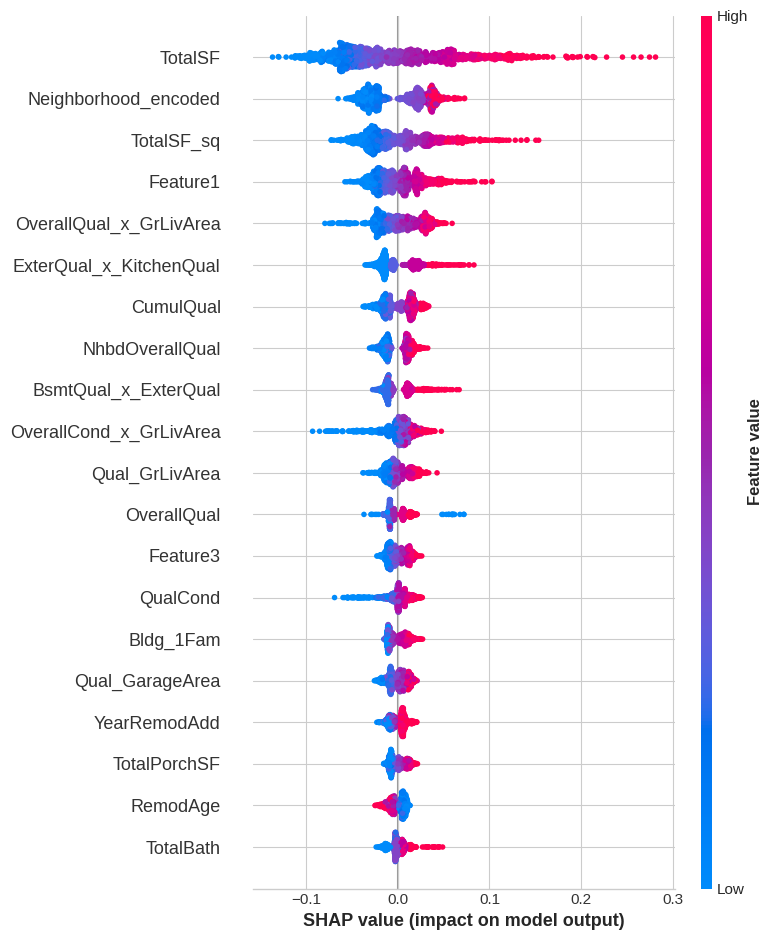

In [29]:
# SHAP analysis + Feature Selection (try/except for import)
try:
    import shap

    # Train a single XGBoost model on full training data
    xgb_full = XGBRegressor(**xgb_params, random_state=RANDOM_STATE,
                            tree_method='hist', device=DEVICE)
    xgb_full.fit(X_train, log_y_train)

    # Create TreeExplainer and compute SHAP values
    explainer = shap.TreeExplainer(xgb_full)
    shap_values = explainer.shap_values(X_train)

    # Top 20 features by mean absolute SHAP value
    importance = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(importance)[-20:][::-1]
    print("[INFO] Top 20 SHAP features:")
    for i in top_idx:
        print(f"  {X_train.columns[i]}: {importance[i]:.6f}")

    # Identify noise features at multiple thresholds
    for pct in [0.01, 0.005, 0.001]:
        threshold = importance.max() * pct
        noise = X_train.columns[importance < threshold]
        print(f"\n[INFO] Noise features (SHAP < {pct*100:.1f}% of max): {len(noise)}")
        if len(noise) <= 30:
            print(f"  {noise.tolist()}")

    # --- ACTUAL FEATURE SELECTION: drop noise, re-run CV ---
    print("\n" + "="*60)
    print("[INFO] Feature Selection: dropping noise features and re-evaluating CV")
    print("="*60)

    thresholds_to_test = [0.0, 0.001, 0.005, 0.01]
    fs_results = []

    for thresh_pct in thresholds_to_test:
        threshold = importance.max() * thresh_pct
        noise_cols = X_train.columns[importance < threshold].tolist()
        keep_cols = [c for c in X_train.columns if c not in noise_cols]
        X_filtered = X_train[keep_cols]

        score = score_dataset(X_filtered, log_y_train)
        fs_results.append({
            "threshold_pct": thresh_pct,
            "n_dropped": len(noise_cols),
            "n_kept": len(keep_cols),
            "score": score
        })
        print(f"  thresh={thresh_pct*100:.1f}% | dropped={len(noise_cols):3d} | kept={len(keep_cols):3d} | score={score:.5f}")

    fs_df = pd.DataFrame(fs_results)
    best_row = fs_df.loc[fs_df['score'].idxmin()]
    print(f"\n[INFO] Best: threshold={best_row['threshold_pct']*100:.1f}%, "
          f"kept={int(best_row['n_kept'])} features, score={best_row['score']:.5f}")

    # --- Apply best threshold to final feature matrices ---
    best_threshold = importance.max() * best_row['threshold_pct']
    noise_cols_final = X_train.columns[importance < best_threshold].tolist()
    print(f"[INFO] Dropping {len(noise_cols_final)} noise features for final pipeline")
    X_train = X_train.drop(columns=noise_cols_final, errors='ignore')
    X_test = X_test.drop(columns=noise_cols_final, errors='ignore')
    print(f"[INFO] Final feature shape: {X_train.shape}")

    # Summary plot (top 20)
    shap.summary_plot(shap_values, X_train, max_display=20, show=False)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("shap not installed, skipping SHAP analysis")
except Exception as e:
    print(f"[WARN] SHAP analysis failed: {e}")

To submit these predictions to the competition, follow these steps:

1. Begin by clicking on the blue **Save Version** button in the top right corner of the window.  This will generate a pop-up window.
2. Ensure that the **Save and Run All** option is selected, and then click on the blue **Save** button.
3. This generates a window in the bottom left corner of the notebook.  After it has finished running, click on the number to the right of the **Save Version** button.  This pulls up a list of versions on the right of the screen.  Click on the ellipsis **(...)** to the right of the most recent version, and select **Open in Viewer**.  This brings you into view mode of the same page. You will need to scroll down to get back to these instructions.
4. Click on the **Output** tab on the right of the screen.  Then, click on the file you would like to submit, and click on the blue **Submit** button to submit your results to the leaderboard.

You have now successfully submitted to the competition!

# Next Steps #

If you want to keep working to improve your performance, select the blue **Edit** button in the top right of the screen. Then you can change your code and repeat the process. There's a lot of room to improve, and you will climb up the leaderboard as you work.

Be sure to check out [other users' notebooks](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/notebooks) in this competition. You'll find lots of great ideas for new features and as well as other ways to discover more things about the dataset or make better predictions. There's also the [discussion forum](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/discussion), where you can share ideas with other Kagglers.

Have fun Kaggling!

---




*Have questions or comments? Visit the [course discussion forum](https://www.kaggle.com/learn/feature-engineering/discussion) to chat with other learners.*